In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/Triplet_Omics_Data')

In [3]:
#Load data and perform necessary preprocessing
rna = sc.read('adata_RNA.h5ad')
print(rna)

spatial_coords = rna.obsm['spatial'].copy()
print(spatial_coords.shape)

rna.var_names_make_unique()
rna = preprocess(rna,modality='rna')

atac = sc.read('adata_ATAC.h5ad')
atac.var_names_make_unique()
atac = preprocess(atac,modality='atac', n_dim=1000)

protein = sc.read('adata_ADT.h5ad')
protein.var_names_make_unique()
protein = preprocess(protein,modality='protein')

AnnData object with n_obs × n_vars = 1296 × 1000
    uns: 'log1p'
    obsm: 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'
(1296, 2)
⚠️ X_lsi not found, performing LSI in Python from count matrix.


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [4]:
features_dict = {
        'rna': rna,        
        'protein': protein,     
        'atac': atac       
    }

initial_weights = [1.0, 1.0, 1.0] 


cfg = GSMOConfig.presets("triplet")


model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg,
            trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

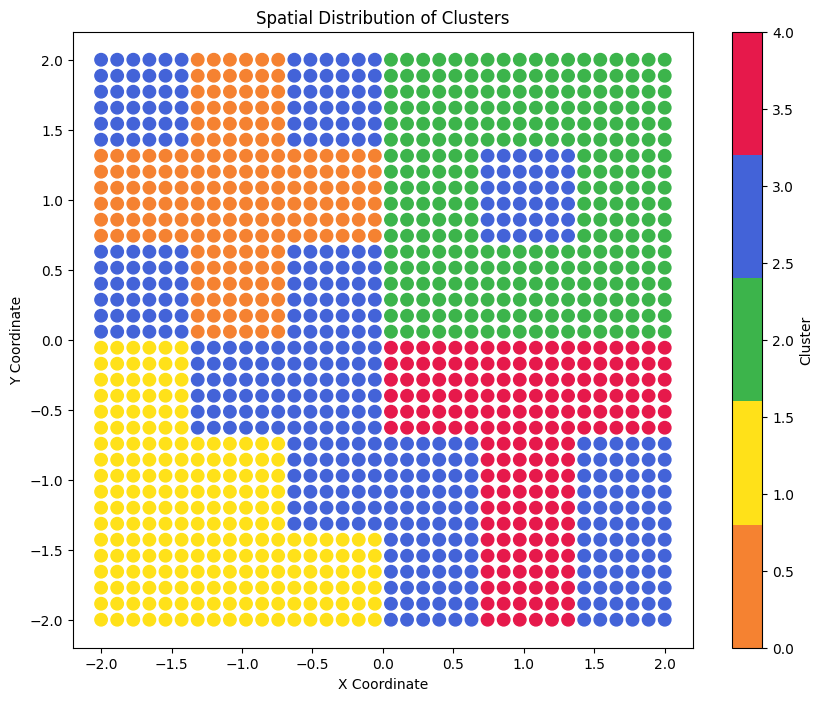

In [6]:
from matplotlib.colors import ListedColormap

plot_color = ['#f58231', '#ffe119', '#3cb44b', '#4363d8', '#e6194b', '#911eb4', '#46f0f0', '#f032e6', 
              '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#ffd8b1', '#800000', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']

rna = sc.read('adata_RNA.h5ad')

rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2, "The RNA data is missing spatial coordinates or has an incorrect format. Please check the data."

clusters = model.cluster_kmeans(n_clusters=5)
# clusters = model.cluster_leiden(n_neighbors=4, resolution=0.03)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y']) 
rna_locs_df['cluster'] = clusters 


num_clusters = len(np.unique(clusters))

if num_clusters > len(plot_color):
    raise ValueError(f"Cluster number {num_clusters} exceeds the number of colors available in the custom palette {len(plot_color)}.")

cmap = ListedColormap(plot_color[:num_clusters])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x'], rna_locs_df['y'], c=rna_locs_df['cluster'], cmap=cmap, s=80)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters")
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()



In [7]:
import pandas as pd
gt_clusters = pd.read_csv("ground_truth_clusters.csv")['cluster'].values

In [8]:
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    mutual_info_score,
    v_measure_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
)

import pandas as pd

def evaluate_clustering_metrics():
    """
    评估聚类结果的多个监督指标
    
    参数：
    - annotation_path: str，GT注释的CSV路径，包含 'manual-anno' 列
    - cluster_labels: 模型聚类结果（顺序应与GT对齐）
    
    返回：
    - scores: dict，包含所有指标名和对应分数
    """
    true_labels = gt_clusters
    cluster_labels = clusters

    scores = {
        "ARI": adjusted_rand_score(true_labels, cluster_labels),
        "Homogeneity": homogeneity_score(true_labels, cluster_labels),
        "Mutual Info": mutual_info_score(true_labels, cluster_labels),
        "V-measure": v_measure_score(true_labels, cluster_labels),
        "AMI": adjusted_mutual_info_score(true_labels, cluster_labels),
        "NMI": normalized_mutual_info_score(true_labels, cluster_labels),
    }

    print("=== Clustering Evaluation Metrics ===")
    for k, v in scores.items():
        print(f"{k}: {v:.4f}")
    
    return scores


scores = evaluate_clustering_metrics()


=== Clustering Evaluation Metrics ===
ARI: 1.0000
Homogeneity: 1.0000
Mutual Info: 1.5474
V-measure: 1.0000
AMI: 1.0000
NMI: 1.0000


In [9]:
# two unsupervised metrics
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq


def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result




/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [10]:
rna.var_names_make_unique()
rna = preprocess(rna,modality='rna')

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [11]:

fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(atac, fused_embeddings, k=50)
print(f"Mean Jaccard ATAC Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(protein, fused_embeddings, k=50)
print(f"Mean Jaccard protein Similarity: {jaccard_mean:.4f}")

morans_I = compute_morans_I(clusters, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")



Calculating Jaccard similarities: 100%|██████████| 1296/1296 [00:00<00:00, 9302.05it/s]


Mean Jaccard RNA Similarity: 0.0724


Calculating Jaccard similarities: 100%|██████████| 1296/1296 [00:00<00:00, 9045.71it/s]


Mean Jaccard ATAC Similarity: 0.1089


Calculating Jaccard similarities: 100%|██████████| 1296/1296 [00:00<00:00, 8930.69it/s]


Mean Jaccard protein Similarity: 0.4656
Moran's I score: 0.8875


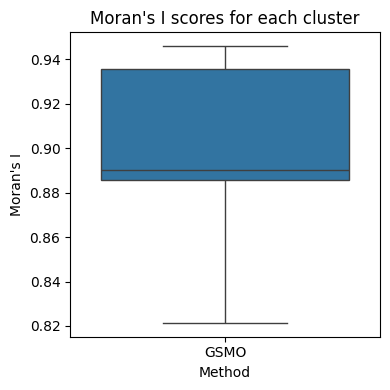

  cluster   moran_I method
0       0  0.890084   GSMO
1       1  0.945988   GSMO
2       2  0.935764   GSMO
3       3  0.821373   GSMO
4       4  0.885514   GSMO


In [12]:
# box plot of moran's I
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):
    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(clusters, spatial_coords, method_name="GSMO")
print(morans_I_df)
